This script will contain the chromatin tracing analysis for mouse replicate 1.

The chromatin tracing has been run with `ecDNATracer` with default parameters. 

Relevant figures can be found in Figure 4, Extended Data Figure 10, 13.

In [1]:
import numpy as np
import os
import pandas as pd

In [2]:
import sys
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

# chromatin tracing: basic analysis

For each cluster, we subsampled ~1500 cells for each cluster to perform chromatin tracing

## load traces

In [3]:
import pickle
with open('D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___in_vivo_mouse\mouse_leiden1500_allecDNA__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)

In [4]:
tr_type = 'Xtraces_chrom_inter_73_253_254'

In [5]:
linear_traces, circ_traces = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces.shape

((1014, 252, 6), (218375, 252, 6))

## get traces by clusters

In [7]:
## this is human only
df_cluster = pd.read_csv('C:/GBM39/in_vivo_mouse/20251009_GBM39_human_cells_in_vivo_mouse_1_metadata.csv')

In [8]:
df_cluster['ifovcell'] = df_cluster['cell_id'].apply(lambda x: int(x.split('_')[-1]))

In [9]:
# Build per-trace ids (same as you did)
fovcell_circ = np.nanmean(circ_traces[:,:, -1], axis=1)

In [10]:
df_cluster_sub = df_cluster[df_cluster['ifovcell'].isin(fovcell_circ)]
df_cluster_sub.shape

(8734, 61)

In [11]:
dic_ifovcell_leiden = dict(zip(df_cluster_sub['ifovcell'], df_cluster_sub['leiden']))

In [12]:
dic_leiden_ifovcell = {}
for cell in dic_ifovcell_leiden:
    leiden = dic_ifovcell_leiden[cell]
    if leiden in dic_leiden_ifovcell.keys():
        dic_leiden_ifovcell[leiden].append(cell)
    else:
        dic_leiden_ifovcell[leiden] = [cell]

In [13]:
dic_leiden_traces = {}
for leiden in sorted(dic_leiden_ifovcell.keys()):
    cells = dic_leiden_ifovcell[leiden]
    sel = circ_traces[np.isin(fovcell_circ, cells)]
    dic_leiden_traces[leiden] = sel

## compute the median distance matrix

In [14]:
dic_leiden_meddist = {}
for leiden in sorted(dic_leiden_ifovcell.keys()):
    leiden_traces = dic_leiden_traces[leiden]
    leiden_mat = np.nanmedian(compute_med_dist_mat(leiden_traces, contact_dist = None), axis = 0)
    dic_leiden_meddist[leiden] = leiden_mat

100%|██████████████████████████████████████████████████████████████████████████████| 618/618 [00:00<00:00, 3987.12it/s]


## compute log contact

In [15]:
dic_leiden_contact = {}
for leiden in sorted(dic_leiden_ifovcell.keys()):
    leiden_traces = dic_leiden_traces[leiden]
    leiden_contact = compute_med_dist_mat(leiden_traces, contact_dist = 0.25)
    dic_leiden_contact[leiden] = leiden_contact

100%|██████████████████████████████████████████████████████████████████████████████| 618/618 [00:00<00:00, 4012.98it/s]


# plot median distance matrix by cluster

## leiden 0 (0_AC)

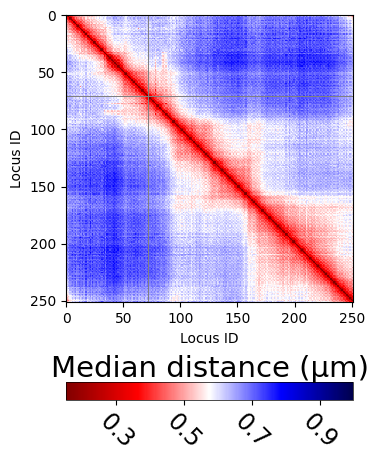

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard


# --- Data & colormap with NaNs as dark gray ---
M0 = dic_leiden_meddist[0]
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.15, vmax=1,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized

ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="6%", pad=0.8)

cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Median distance (µm)' , fontsize=21)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelrotation=-45, labelsize=17)
cbar.outline.set_linewidth(0.5)

ticks = np.arange(0.3, 1.0, 0.2)
cbar.set_ticks(ticks)

# fig.tight_layout()

### leiden 0 zoom in

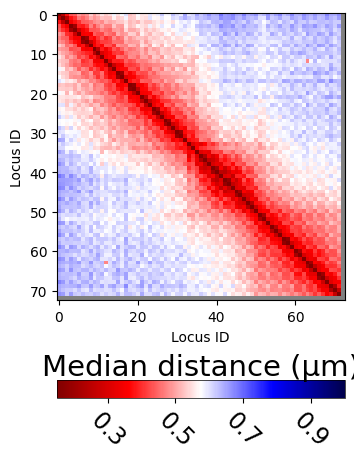

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard


# --- Data & colormap with NaNs as dark gray ---
M0 = dic_leiden_meddist[0]
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0[0:73, 0:73], cmap=cmap, vmin=0.15, vmax=1,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized

ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="6%", pad=0.8)

cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Median distance (µm)' , fontsize=21)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelrotation=-45, labelsize=17)
cbar.outline.set_linewidth(0.5)

ticks = np.arange(0.3, 1.0, 0.2)
cbar.set_ticks(ticks)

# fig.tight_layout()

## leiden 1 (1_MES)

In [20]:
1.5* 0.76

1.1400000000000001

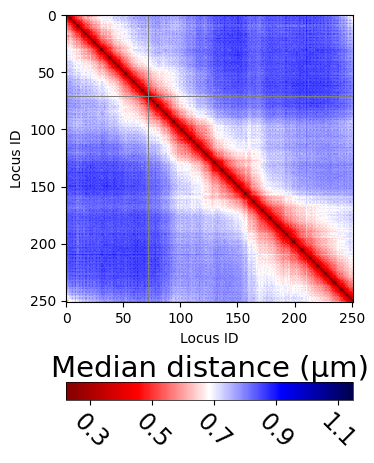

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard


# --- Data & colormap with NaNs as dark gray ---
M0 = dic_leiden_meddist[1]
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.22, vmax=1.15,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="6%", pad=0.8)

cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Median distance (µm)' , fontsize=21)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelrotation=-45, labelsize=17)
cbar.outline.set_linewidth(0.5)

ticks = np.arange(0.3, 1.3, 0.2)
cbar.set_ticks(ticks)

### leiden 1 zoom in

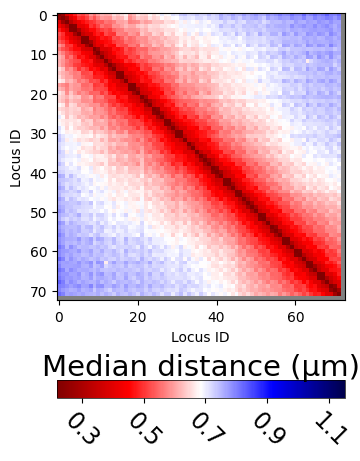

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard


# --- Data & colormap with NaNs as dark gray ---
M0 = dic_leiden_meddist[1]
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0[0:73, 0:73], cmap=cmap, vmin=0.22, vmax=1.15,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="6%", pad=0.8)

cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Median distance (µm)' , fontsize=21)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelrotation=-45, labelsize=17)
cbar.outline.set_linewidth(0.5)

ticks = np.arange(0.3, 1.3, 0.2)
cbar.set_ticks(ticks)

## difference: 0_AC - 1_MES

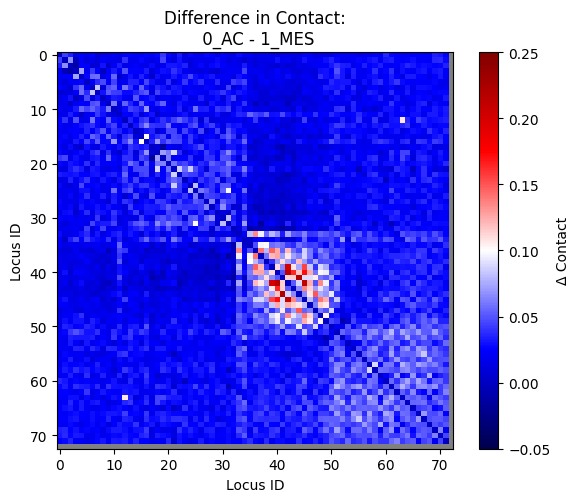

In [22]:
## difference in contact
M_diff = dic_leiden_contact[0] - dic_leiden_contact[1]
M_diff[72, :] = np.NaN
M_diff[:, 72] = np.NaN

# get your base cmap
cmap = plt.cm.seismic.copy()

# set NaN (bad) color to dark gray
cmap.set_bad(color='#808080')


fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M_diff[0:73, 0:73], cmap=cmap, vmin=-0.05, vmax=0.25,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')
ax.set_title('Difference in Contact:\n 0_AC - 1_MES')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Contact')

fig.tight_layout()

## leiden 4 (4_MES)

This is the cluster with structual variant

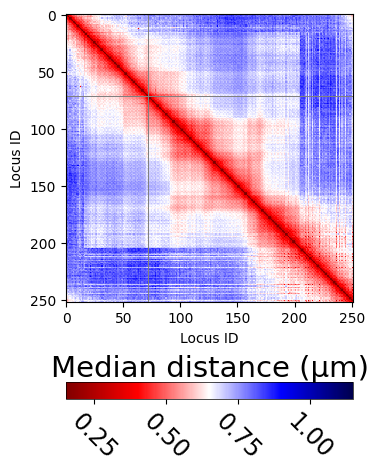

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard


# --- Data & colormap with NaNs as dark gray ---
M0 = dic_leiden_meddist[4]
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.15, vmax=1.15,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="6%", pad=0.8)

cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Median distance (µm)' , fontsize=21)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelrotation=-45, labelsize=17)
cbar.outline.set_linewidth(0.5)


### detection efficiency

In [40]:
def compute_detection_efficiency(X, coord_cols=(0, 1, 2), show_plot=True):
    """
    Computes and optionally plots per-bin detection efficiency across traces.

    Parameters:
    - X: array of shape (N, 252, D), e.g., (N, 252, 6)
    - coord_cols: which columns define valid detection (default: first 3: z, x, y)
    - show_plot: if True, show a line plot of detection efficiency

    Returns:
    - efficiency: array of shape (252,) with values in [0, 1]
    """
    import numpy as np
    import matplotlib.pyplot as plt

    is_valid = ~np.isnan(X[:, :, coord_cols]).any(axis=-1)  # shape: (N, 252)
    efficiency = is_valid.sum(axis=0) / X.shape[0]  # shape: (252,)

    return efficiency


In [41]:
leiden4_eff = compute_detection_efficiency(dic_leiden_traces[4])

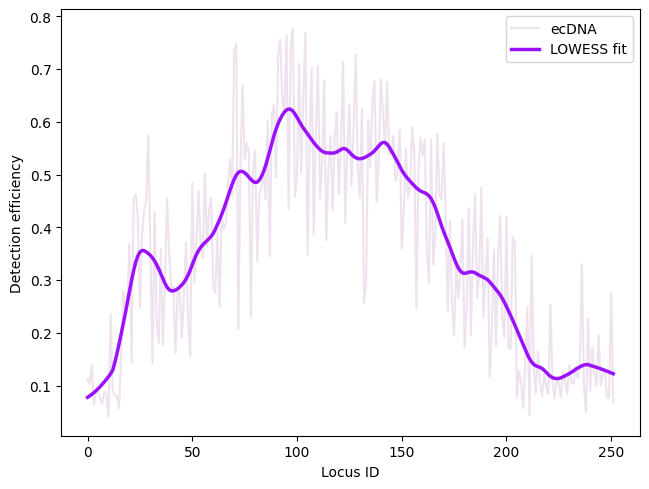

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

y = np.asarray(leiden4_eff, dtype=float)
x = np.arange(y.size)

# handle NaNs
ok = ~np.isnan(y)
y_fit = np.full_like(y, np.nan, dtype=float)
y_fit[ok] = lowess(y[ok], x[ok], frac=0.1, it=0, return_sorted=False)  # frac≈0.05–0.2 controls smoothness

plt.plot(x, y, lw=1.5, alpha=0.3, label='ecDNA', color = '#C8A2C8')
plt.plot(x, y_fit, lw=2.5, label='LOWESS fit', color = '#9A10FF') 
plt.legend()
plt.tight_layout()
plt.xlabel('Locus ID')
plt.ylabel('Detection efficiency')
# plt.savefig(r'C:/GBM39/manuscript_figures/mouse_fig2/plots/SV/leiden4_detection_eff_with_fitted_line.svg')
plt.show()


# centrality score

In [32]:
import numpy as np

def centrality_ecdna(
    X, 
    egfr_mask,                    # boolean array shape (252,) marking ~30 EGFR bins
    egfr_promoter_idx=None,       # int index of the promoter bin, or None
    min_frac_detect=0.60,         # require ≥60% bins detected for a valid score
    min_frac_egfr_detect=0.50,    # require ≥50% of EGFR bins detected
    leave_one_out=False           # use leave-one-out D̄ when computing each C_i
):
    """
    Compute centroid-based centrality for an ecDNA trace.

    Parameters
    ----------
    X : (252, 6) float array
        ecDNA trace; columns [z, x, y, ...] with NaNs allowed.
    egfr_mask : (252,) bool
        True for bins that belong to the EGFR amplicon (~30 bins).
    egfr_promoter_idx : int or None
        Index of the promoter bin (if you want a promoter-centric score).
    min_frac_detect : float
        Minimum fraction of detected bins in the domain required.
    min_frac_egfr_detect : float
        Minimum fraction of detected EGFR bins required for EGFR-region scores.
    leave_one_out : bool
        If True, for each bin i compute C_i with D̄ excluding i.

    Returns
    -------
    out : dict
        {
          'centroid': (3,),
          'Dbar': float,
          'C_per_bin': (252,) with NaN for undetected bins,
          'promoter_C': float or NaN,
          'egfr_region_C_mean': float or NaN,
          'egfr_region_C_median': float or NaN,
          'egfr_region_C_best': float or NaN,
          'egfr_region_C_worst': float or NaN,
          'n_detected': int,
          'n_detected_egfr': int
        }
    """
    # pull coords and detection mask
    coords = X[:, :3]                  # z, x, y
    valid = np.all(np.isfinite(coords), axis=1)

    n_total = coords.shape[0]
    n_detected = int(valid.sum())
    if n_detected < int(np.ceil(min_frac_detect * n_total)):
        # not enough loci to define a robust centroid
        return {
            'centroid': np.array([np.nan, np.nan, np.nan]),
            'Dbar': np.nan,
            'C_per_bin': np.full(n_total, np.nan),
            'promoter_C': np.nan,
            'egfr_region_C_mean': np.nan,
            'egfr_region_C_median': np.nan,
            'egfr_region_C_best': np.nan,
            'egfr_region_C_worst': np.nan,
            'n_detected': n_detected,
            'n_detected_egfr': int((valid & egfr_mask).sum())
        }

    # centroid over detected bins
    mu = np.nanmean(coords[valid], axis=0)   # shape (3,)

    # distances to centroid for detected bins
    diffs = coords[valid] - mu
    d = np.linalg.norm(diffs, axis=1)        # shape (n_detected,)

    # mean distance over domain
    Dbar = d.mean()

    # centrality per detected bin
    if leave_one_out and n_detected > 1:
        sum_d = d.sum()
        Dbar_excl = (sum_d - d) / (n_detected - 1)            # per-bin D̄(-i)
        C_detected = 1.0 - (d / Dbar_excl)
    else:
        C_detected = 1.0 - (d / Dbar)

    # scatter back into full-length array
    C_per_bin = np.full(n_total, np.nan, dtype=float)
    C_per_bin[valid] = C_detected

    # promoter centrality (if requested and detected)
    promoter_C = np.nan
    if egfr_promoter_idx is not None and 0 <= egfr_promoter_idx < n_total:
        promoter_C = C_per_bin[egfr_promoter_idx]

    # EGFR region summaries
    egfr_valid = valid & egfr_mask
    n_detected_egfr = int(egfr_valid.sum())

    egfr_region_C_mean = np.nan
    egfr_region_C_median = np.nan
    egfr_region_C_best = np.nan
    egfr_region_C_worst = np.nan

    if n_detected_egfr >= int(np.ceil(min_frac_egfr_detect * egfr_mask.sum())):
        # distance-based aggregation
        d_all = np.full(n_total, np.nan)
        d_all[valid] = d
        d_egfr = d_all[egfr_valid]

        egfr_region_C_mean   = 1.0 - (np.nanmean(d_egfr)   / Dbar)
        egfr_region_C_median = 1.0 - (np.nanmedian(d_egfr) / Dbar)

        C_egfr = C_per_bin[egfr_valid]
        if C_egfr.size > 0 and not np.all(np.isnan(C_egfr)):
            egfr_region_C_best  = np.nanmax(C_egfr)
            egfr_region_C_worst = np.nanmin(C_egfr)

    return {
        'centroid': mu,
        'Dbar': float(Dbar),
        'C_per_bin': C_per_bin,
        'promoter_C': float(promoter_C) if np.isfinite(promoter_C) else np.nan,
        'egfr_region_C_mean': float(egfr_region_C_mean) if np.isfinite(egfr_region_C_mean) else np.nan,
        'egfr_region_C_median': float(egfr_region_C_median) if np.isfinite(egfr_region_C_median) else np.nan,
        'egfr_region_C_best': float(egfr_region_C_best) if np.isfinite(egfr_region_C_best) else np.nan,
        'egfr_region_C_worst': float(egfr_region_C_worst) if np.isfinite(egfr_region_C_worst) else np.nan,
        'n_detected': n_detected,
        'n_detected_egfr': n_detected_egfr
    }


def compute_centrality_all_traces(circular_traces, egfr_mask, egfr_promoter_idx, 
                                  min_frac_detect = 0, min_frac_egfr_detect=0):
    """
    Compute promoter centrality and per-locus centrality for many traces.

    Parameters
    ----------
    circular_traces : (N, 252, 6) array
        All ecDNA traces (NaN allowed, coords in [:, :3]).
    egfr_mask : (252,) bool
        Mask marking EGFR bins.
    egfr_promoter_idx : int
        Index of the EGFR promoter bin.

    Returns
    -------
    promoter_scores : (N,) array
        Promoter centrality score per trace.
    locus_scores : (N, 252) array
        Centrality score per locus per trace (NaN where not detected).
    """
    N = circular_traces.shape[0]
    promoter_scores = np.full(N, np.nan, dtype=float)
    locus_scores = np.full((N, 252), np.nan, dtype=float)

    for i in range(N):
        out = centrality_ecdna(
            circular_traces[i],
            egfr_mask=egfr_mask,
            egfr_promoter_idx=egfr_promoter_idx,
            min_frac_detect = min_frac_detect,
            min_frac_egfr_detect = min_frac_egfr_detect
        )
        promoter_scores[i] = out['promoter_C']
        locus_scores[i] = out['C_per_bin']

    return promoter_scores, locus_scores


In [34]:
egfr_mask = np.zeros(252, dtype=bool)
egfr_mask[50:83] = True
# slice is [49, 83) → covers 49–82 inclusive

egfr_promoter_idx = 50

In [35]:
dic_leiden_centrality = {}
for leiden in [0,1]:
    _, locus_scores_leiden = compute_centrality_all_traces(
    dic_leiden_traces[leiden],
    egfr_mask,
    egfr_promoter_idx
)
    dic_leiden_centrality[leiden] = locus_scores_leiden

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_18008\1805137814.py:108: RuntimeWarning: Mean of empty slice
  egfr_region_C_mean   = 1.0 - (np.nanmean(d_egfr)   / Dbar)
C:\Users\RenLabUser\anaconda3\envs\cellpose_upgrade\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [37]:
leiden_colors = ['#86E300', '#CA2800', '#F328A2', '#00008E', '#9A10FF', '#1C5951', '#20D2FF']

In [107]:
leiden_names = ["0_AC", "1_MES", "2_MES", "3_MES", "4_MES", "5_MES", "6_OPC"]
dic_leiden_colors = dict(zip(leiden_names, leiden_colors))

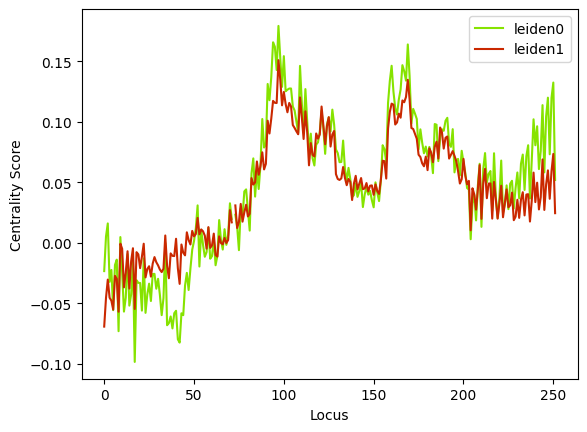

In [38]:
vals_l0 = np.nanmedian(dic_leiden_centrality[0], axis=0)
vals_l1  = np.nanmedian(dic_leiden_centrality[1], axis=0)
vals_l0[72] = np.NaN
vals_l1[72] = np.NaN
plt.plot(range(252), vals_l0, label = 'leiden0', color=leiden_colors[0])
plt.plot(range(252), vals_l1, label = 'leiden1', color=leiden_colors[1])
plt.legend()
plt.xlabel('Locus')
plt.ylabel('Centrality Score')

# Ensure lines are not rasterized (usually unnecessary, but explicit is nice)
for line in plt.gca().lines:
    line.set_rasterized(False)

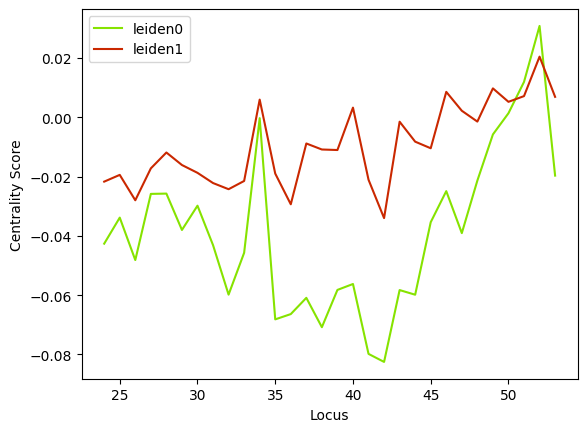

In [39]:
istart = 24
iend = 54

vals_l0 = np.nanmedian(dic_leiden_centrality[0], axis=0)[istart:iend]
vals_l1  = np.nanmedian(dic_leiden_centrality[1], axis=0)[istart:iend]


plt.plot(range(istart,iend), vals_l0, label = 'leiden0', color=leiden_colors[0])
plt.plot(range(istart,iend), vals_l1, label = 'leiden1', color=leiden_colors[1])
plt.legend()
plt.xlabel('Locus')
plt.ylabel('Centrality Score')
   
# Ensure lines are not rasterized (usually unnecessary, but explicit is nice)
for line in plt.gca().lines:
    line.set_rasterized(False)

# structural variants

Within the 4_MES population, we have discovered cells with chromatin traces that have a partial deletion (i.e. structural variant)

## intron expression (SV vs. ecEGFR+ clusters)

In [54]:
# ==== config ====
sample_key  = "sample"
samples     = ["ecEGFR+ cluster", "4_MES"]      # left-to-right in split & legend
palette     = {"4_MES":"#9A10FF", "ecEGFR+ cluster":"#FFD700"} #FFD700 #1f77b4 matplotlib blue
ylim        = (0, 600)
inner       = "quartile"
add_strip   = True
jitter      = 0.12

In [47]:
df_counts_human = pd.read_csv(r'C:/GBM39/in_vivo_mouse/20251110__df_leiden1500_introns__in_vivo_mouse.csv', index_col = 0)
df_counts_human['ifovcell'] = df_counts_human.index

In [48]:
df_counts_human

,iQ20,iQ22,iQ24,iQ26,iQ30,iQ32,iQ39,iQ41,iQ44,iQ48,ifovcell
2200009,16.0,13.0,20.0,8.0,12.0,15.0,16.0,19.0,42.0,7.0,2200009
2200018,3.0,12.0,13.0,12.0,6.0,9.0,12.0,11.0,20.0,10.0,2200018
2200020,11.0,48.0,25.0,10.0,4.0,14.0,8.0,12.0,16.0,10.0,2200020
2200029,20.0,25.0,25.0,19.0,9.0,16.0,30.0,29.0,38.0,16.0,2200029
2200030,16.0,31.0,28.0,17.0,15.0,21.0,28.0,30.0,53.0,14.0,2200030
...,...,...,...,...,...,...,...,...,...,...,...
37301143,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,41.0,0.0,37301143
37301284,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,62.0,0.0,37301284
37301314,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,37301314
37301381,6.0,7.0,4.0,10.0,3.0,6.0,7.0,8.0,63.0,6.0,37301381


In [50]:
chr7_iQs = [20, 22, 24, 26, 30, 32, 37, 39, 41, 44, 48]
chr7_introns= ['EGFR-AS1_introns',
 'EGFR_introns',
 'FKBP9P1_introns',
 'LANCL2_introns',
 'MRPS17_introns',
 'NIPSNAP2_introns',
 'PSPHP1_introns',
 'PSPH_introns',
 'SEPTIN14_introns',
 'VOPP1_introns',
 'ZNF713_introns']
dic_iQ_to_gene = dict(zip(chr7_iQs, chr7_introns))
chr7_iQs_sorted = [22, 20, 26, 24, 41, 48, 30, 32, 39]

In [57]:
import numpy as np
import pandas as pd

# inputs assumed in session:
# df_counts_human (rows=ifovcell), df_cluster[['ifovcell','leiden']]
# chr7_iQs_sorted: list[int]
# dic_iQ_to_gene: dict[int->str]  (use for x tick labels)

# --- unique map ifovcell -> leiden
leiden_map = (df_cluster.dropna(subset=['ifovcell','leiden'])
                         .drop_duplicates('ifovcell', keep='last')
                         .set_index('ifovcell')['leiden'])
try: leiden_map = leiden_map.astype(int)
except: pass

# keep overlapping cells
common = df_counts_human.index.intersection(leiden_map.index)
dfX = df_counts_human.loc[common].copy()
leiden_map = leiden_map.loc[common]

# group labels for hue
sample_label = pd.Series(np.where(leiden_map.eq(4), '4_MES', 'ecEGFR+ cluster'),
                         index=leiden_map.index, name='sample')

# columns in the desired order (tolerant to different naming)
cols = []
x_order = []
for iq in chr7_iQs_sorted:
    # prefer gene name, then "GENE__iq", then "iQ{iq}"
    candidates = []
    if dic_iQ_to_gene and iq in dic_iQ_to_gene:
        g = dic_iQ_to_gene[iq]
        candidates += [g, f"{g}__{iq}"]
    candidates.append(f"iQ{iq}")
    found = next((c for c in candidates if c in dfX.columns), None)
    if found is None:
        # create placeholder so order is preserved (will drop NaNs later)
        found = f"iQ{iq}__MISSING"
        if found not in dfX.columns:
            dfX[found] = np.nan
    cols.append(found)
    x_order.append(dic_iQ_to_gene[iq].replace('_introns', '') if (dic_iQ_to_gene and iq in dic_iQ_to_gene)
                   else found.split('__')[0])

# build long table
long = (
    dfX[cols]
    .assign(ifovcell=dfX.index)
    .melt(id_vars='ifovcell', var_name='gene_col', value_name='expr')
    .dropna(subset=['expr'])
)

# pretty gene labels using dic_iQ_to_gene/x_order mapping
# strip disambiguation suffix for display
# long['gene'] = long['gene_col'].str.split('__').str[0]
long['gene'] = long['gene_col'].apply(lambda x: dic_iQ_to_gene[int(x.split('iQ')[-1])].replace('_introns', ''))
# attach sample label
T = long.join(sample_label, on='ifovcell')[['gene', 'expr', 'sample']]

In [58]:
T['log2_expr'] = np.log2(T['expr']+1)

In [59]:
T

,gene,expr,sample,log2_expr
0,EGFR,13.0,ecEGFR+ cluster,3.807355
1,EGFR,12.0,ecEGFR+ cluster,3.700440
2,EGFR,48.0,4_MES,5.614710
3,EGFR,25.0,ecEGFR+ cluster,4.700440
4,EGFR,31.0,4_MES,5.000000
...,...,...,...,...
163831,PSPH,0.0,ecEGFR+ cluster,0.000000
163832,PSPH,0.0,ecEGFR+ cluster,0.000000
163833,PSPH,1.0,ecEGFR+ cluster,1.000000
163834,PSPH,7.0,ecEGFR+ cluster,3.000000


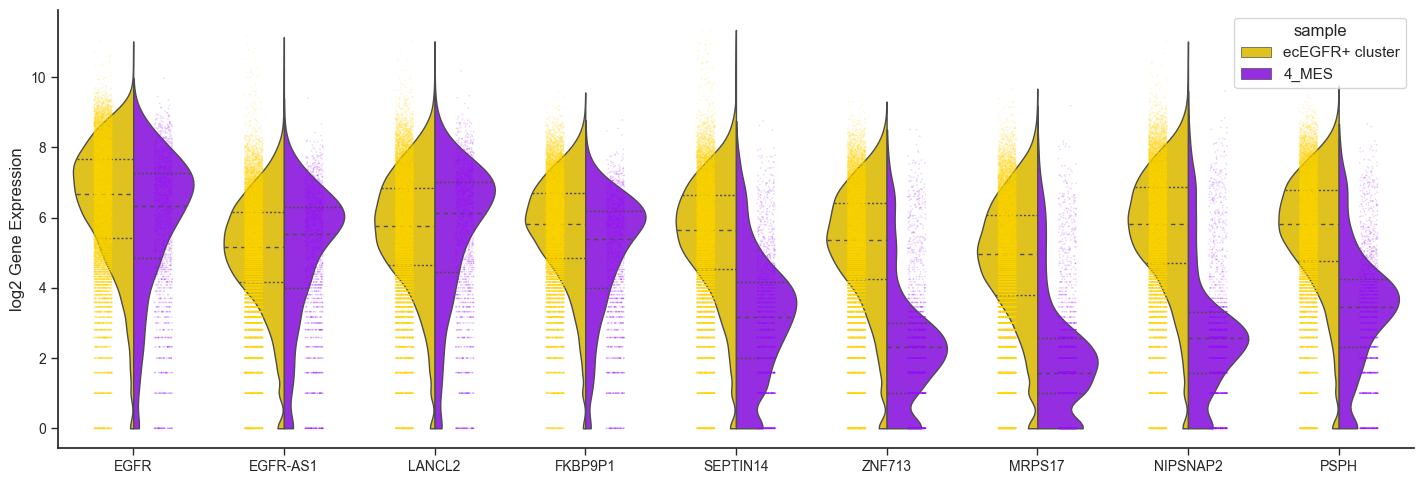

In [60]:
# log2 ver
sns.set(style="white")
mpl.rcParams["svg.fonttype"] = "none"

fig, ax = plt.subplots(figsize=(1.6*len(x_order), 5.0))

sns.violinplot(
    data=T, x="gene", y="log2_expr",
    hue="sample", order=x_order, hue_order=samples,
    split=True, cut=0, scale="width", inner=inner,
    linewidth=1, palette=palette, ax=ax
)

if add_strip:
    sns.stripplot(
        data=T, x="gene", y="log2_expr",
        hue="sample", order=x_order, hue_order=samples,
        dodge=True, jitter=jitter, alpha=0.18, size=1.2,
        palette=palette, linewidth=0, ax=ax
    )

# single legend (avoid duplicate from stripplot)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(samples)], labels[:len(samples)],
          title="sample", loc="upper right", frameon=True)

# --- cosmetics: no grid, but keep ticks ---
ax.grid(False)                              # remove grid lines
# ax.set_ylim(*ylim)
ax.set_ylabel("log2 Gene Expression")
ax.set_xlabel("")
ax.tick_params(axis="x", labelrotation=0,
               bottom=True, top=False, length=5, width=1, labelsize=10)
ax.tick_params(axis="y",
               left=True, right=False, length=5, width=1, labelsize=10)

# nice y ticks at integers 0..7 (match ylim)
import numpy as np
# ax.set_yticks(np.arange(int(ylim[0]), int(ylim[1]) + 1, 1))
# keep left/bottom spines, hide top/right
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# rasterize heavy artists, keep text/axes vector
for coll in ax.collections:
    try: coll.set_rasterized(True)
    except Exception: pass
for t in ax.texts:
    t.set_rasterized(False)

plt.show()

## lineage tracing

The leiden clusters were decided based on transcriptional profiles. Are there cells outside of this cluster that has the SV?

### identify SV traces

In [61]:
import numpy as np

def subset_traces_with_empty_window(
    traces: np.ndarray,
    istart: int,
    iend: int,
    coord_cols=(0, 1, 2),
    empty_frac: float = 0.95,
):
    """
    Return traces where >= empty_frac of loci in [istart, iend] are empty (NaN).

    Parameters
    ----------
    traces : (N, L, D) array
        Typically (N, 252, 6). L is the number of loci, D >= 3.
    istart, iend : int
        Inclusive locus bounds. Will be clipped to [0, L-1].
    coord_cols : tuple[int]
        Columns used to assess emptiness (any NaN across these = empty).
        Default (0,1,2) for z/x/y.
    empty_frac : float
        Threshold fraction of empty loci required to consider a match (default 0.95).

    Returns
    -------
    traces_matched : (M, L, D) array
        Subset of traces that match the criterion.
    idx_matched : (M,) array
        Indices of matching traces in the original array.
    empty_fraction_per_trace : (M,) array
        Fraction of empty loci within the window for each matched trace.
    """
    assert traces.ndim == 3, "traces must be (N, L, D)"
    N, L, D = traces.shape
    a = max(0, min(istart, iend))
    b = min(L - 1, max(istart, iend))  # inclusive
    if b < a:
        raise ValueError("Empty locus window after clipping. Check istart/iend.")

    # Slice window and select coordinate columns
    window = traces[:, a:b+1, :]                    # (N, W, D)
    window_xyz = window[:, :, list(coord_cols)]     # (N, W, len(coord_cols))

    # A locus is "empty" if ANY of the coord_cols is NaN
    is_empty = np.isnan(window_xyz).any(axis=-1)    # (N, W)
    W = is_empty.shape[1]
    frac_empty = is_empty.sum(axis=1) / float(W)    # (N,)

    match_mask = frac_empty >= empty_frac
    idx_matched = np.nonzero(match_mask)[0]
    return traces[match_mask], idx_matched, frac_empty[match_mask]


In [62]:
matched_traces, matched_idxs, matched_fracs = subset_traces_with_empty_window(circ_traces, istart=200, iend=252, coord_cols=(0,1,2), empty_frac=0.95)
print("Matched array shape:", matched_traces.shape)

Matched array shape: (10177, 252, 6)


In [63]:
matched_traces_, _, _ = subset_traces_with_empty_window(matched_traces, istart=0, iend=10, coord_cols=(0,1,2), empty_frac=0.95)
print("Matched array shape:", matched_traces_.shape)

Matched array shape: (9729, 252, 6)


In [70]:
SV_cells = np.nanmean(matched_traces_[:,:,-1], axis = 1)

In [72]:
svid, svcts = np.unique(SV_cells, return_counts = True)

In [73]:
df_sv = pd.DataFrame({'cell_id': svid, 'num_SV_traces': svcts})
df_sv

,cell_id,num_SV_traces
0,22300023.0,5
1,22300030.0,8
2,22300036.0,10
3,22300048.0,23
4,22300057.0,5
...,...,...
981,33801010.0,9
982,33801025.0,1
983,33801069.0,6
984,33801146.0,1


In [74]:
df_cell_pos = np.load(r'X:\Brett\DataFramesV2\cell_df_1p5thV2.pkl', allow_pickle = True)

In [79]:
df_plot = pd.merge(df_cell_pos, df_sv, on = 'cell_id', how = 'left')

### plot spatial distribution

In [65]:
def plot_cells_by_tracecount(
    df,
    x_col='x_um_abs',
    y_col='y_um_abs',
    traces_col='num_of_traces',
    traces_col_label=None,
    s=6,
    alpha=0.9,
    vmin=None,
    vmax=None,
    invert_y=False,
    invert_x=False,
    equal_aspect=True,
    nan_color='0.5',
    nan_alpha=0.6,
    nan_size_factor=0.3,
    swap_xy=False,
    scale_size=True,
    size_min=4,
    size_max=20,
    # NEW: colorbar size controls (fractions of axis)
    cbar_width_frac=0.5,    # 0–1, shorter bar
    cbar_height_frac=0.05,  # thickness
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()
    c = df[traces_col].to_numpy()

    if swap_xy:
        x, y = y, x

    finite = np.isfinite(c)

    fig, ax = plt.subplots(figsize=(6, 5), facecolor='black')
    ax.set_facecolor('black')

    # ---- gray NaNs first ----
    if np.any(~finite):
        ax.scatter(
            x[~finite], y[~finite],
            s=s * nan_size_factor,
            alpha=nan_alpha,
            color=nan_color,
            linewidth=0,
            edgecolors='none',
            zorder=1,
        )

    # ---- colored points ----
    x_f = x[finite]
    y_f = y[finite]
    c_f = c[finite]

    vmin_eff = np.nanmin(c_f) if vmin is None else vmin
    vmax_eff = np.nanmax(c_f) if vmax is None else vmax
    norm = Normalize(vmin=vmin_eff, vmax=vmax_eff)

    if scale_size:
        v_norm = np.clip(norm(c_f), 0, 1)
        sizes = size_min + v_norm * (size_max - size_min)
    else:
        sizes = np.full_like(c_f, fill_value=s, dtype=float)

    # draw smaller values first
    order = np.argsort(c_f)
    x_f, y_f, c_f, sizes = x_f[order], y_f[order], c_f[order], sizes[order]

    sc = ax.scatter(
        x_f, y_f,
        c=c_f,
        cmap='plasma',
        vmin=vmin_eff,
        vmax=vmax_eff,
        s=sizes,
        alpha=alpha,
        linewidth=0,
        edgecolors='none',
        zorder=2,
    )

    # ---- short horizontal colorbar at bottom ----
    if traces_col_label is None:
        traces_col_label = traces_col

    # inset axis under main plot, centered
    cax = inset_axes(
        ax,
        width=f"{cbar_width_frac*100:.0f}%",   # e.g. "50%"
        height=f"{cbar_height_frac*100:.0f}%", # e.g. "5%"
        loc='lower center',
        bbox_to_anchor=(0, -0.12, 1, 1),       # move below axes
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
    cb.set_label(traces_col_label, color='white')
    cb.ax.xaxis.set_tick_params(color='white')
    for t in cb.ax.get_xticklabels():
        t.set_color('white')

    # clean axes
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if equal_aspect:
        ax.set_aspect('equal', 'box')
    if invert_y:
        ax.invert_yaxis()
    if invert_x:
        ax.invert_xaxis()

    plt.tight_layout()
    plt.show()
    return fig, ax


C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_18008\1719440479.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


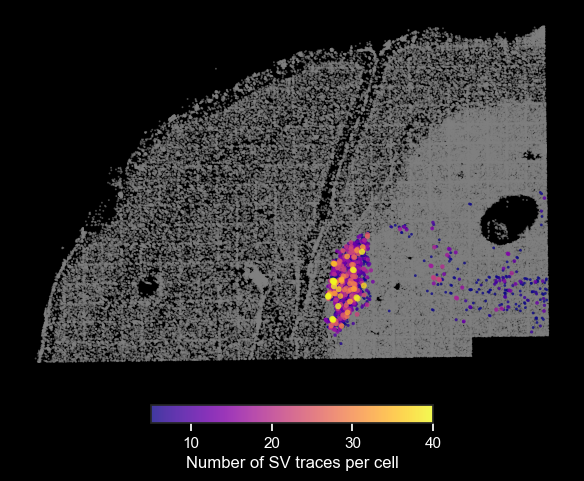

In [81]:
fig, ax = plot_cells_by_tracecount(
    df_plot,
    traces_col='num_SV_traces',
    traces_col_label='Number of SV traces per cell',
    alpha = 0.8,
    swap_xy=True,
    invert_y=True,
    invert_x=True,
    scale_size=True,
    
     vmin = 5, vmax = 40
    
)


In [ ]:
df_plot.to_csv(r'C:/GBM39/in_vivo_mouse/df_SV_traces_frac__in_vivo_mouse.csv')

### plot stack bar plots

In [116]:
df_plot_prop = pd.merge(df_cluster[['ifovcell', 'butterfly_state_cluster']].rename(columns = {'ifovcell': 'cell_id'}),
                                                                    df_plot, on = 'cell_id', how = 'inner')

In [117]:
df_bar = df_plot_prop[np.isfinite(df_plot_prop['num_SV_traces'])]['butterfly_state_cluster'].value_counts(normalize = True).reset_index()
df_bar.columns = ['butterfly_state_cluster', 'prop_SV']

In [118]:
df_bar

,butterfly_state_cluster,prop_SV
0,4_MES,0.883062
1,1_MES,0.087172
2,0_AC,0.013466
3,5_MES,0.011339
4,3_MES,0.002126
5,6_OPC,0.001417
6,2_MES,0.001417


In [98]:
import numpy as np
import matplotlib.pyplot as plt


def plot_cluster_stacked_bar(
    df_plot,
    cluster_col,
    prop_col,
    *,
    leiden_colors,
    order=None,
    ax=None,
    bar_width=0.6,
    show_percent_text=True,
    percent_fmt="{:.0f}%",
    text_color="black",
    fontsize=10,
    title=None,
    ylabel="Percentage of cells",
    xlabel="SV+ cells",
    n_label=None,  # e.g., "N = 1,094"
):
    """
    Plot a single stacked bar of cluster proportions.

    Parameters
    ----------
    df_plot : pd.DataFrame
        Must contain cluster_col and prop_col.
        prop_col should be fractions (0–1) or percentages (0–100).
    cluster_col : str
    prop_col : str
    leiden_colors : dict
        Mapping {cluster_name: color}
    order : list, optional
        Order of clusters (bottom -> top). If None, use df order.
    ax : matplotlib axis
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 4))

    df = df_plot.copy()

    # Ensure proper order
    if order is not None:
        df = df.set_index(cluster_col).loc[order].reset_index()

    # Normalize to fraction if needed
    vals = df[prop_col].values.astype(float)
    if vals.max() > 1.0:
        vals = vals / 100.0

    clusters = df[cluster_col].values

    bottom = 0.0

    for cl, v in zip(clusters, vals):
        color = leiden_colors.get(cl, "gray")

        ax.bar(
            0,
            v,
            bottom=bottom,
            width=bar_width,
            color=color,
            edgecolor="white"
        )

        # Add percent text
        if show_percent_text and v > 0.02:
            ax.text(
                0,
                bottom + v / 2,
                percent_fmt.format(v * 100),
                ha="center",
                va="center",
                fontsize=fontsize,
                color=text_color
            )

        bottom += v

    # Axis formatting
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylabel(ylabel)
    ax.set_xticks([0])

    xtick_label = xlabel
    if n_label is not None:
        xtick_label += f"\n{n_label}"
    ax.set_xticklabels([xtick_label])

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=leiden_colors.get(cl, "gray"))
        for cl in clusters
    ]
    ax.legend(
        handles,
        clusters,
        title="GBM Cluster",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )

    if title:
        ax.set_title(title)

    return ax

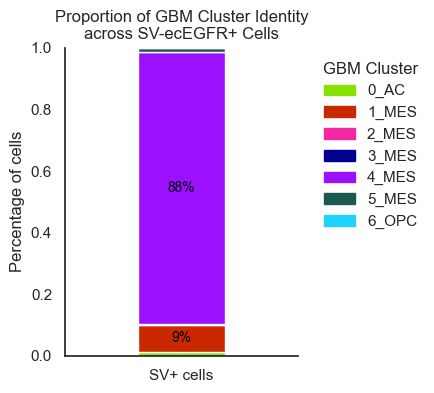

In [120]:
plot_cluster_stacked_bar(
    df_bar,
    cluster_col="butterfly_state_cluster",
    prop_col="prop_SV",
    leiden_colors=dic_leiden_colors,
    order=["0_AC", "1_MES", "2_MES", "3_MES", "4_MES", "5_MES", "6_OPC"],
    n_label=None,
    title="Proportion of GBM Cluster Identity\nacross SV-ecEGFR+ Cells"
)
plt.show()